In [1]:
'''
Here in this data set,

We tested the sign inversion found in Fig 1 of Raynes, Y., Wylie, C.S., Sniegowski, P.D. and Weinreich, D.M., 2018. 
Sign of selection on mutation rate modifiers depends on population size. Proceedings of the National Academy of Sciences, 
115(13), pp.3422-3427.

Using the parameters of mutation rate and selection coefficent of our model.

'''

'\nHere in this data set,\n\nWe tested the sign inversion found in Fig 1 of Raynes, Y., Wylie, C.S., Sniegowski, P.D. and Weinreich, D.M., 2018. \nSign of selection on mutation rate modifiers depends on population size. Proceedings of the National Academy of Sciences, \n115(13), pp.3422-3427.\n\nUsing the parameters of mutation rate and selection coefficent of our model.\n\n'

In [2]:
from __future__ import division
import numpy as np
from scipy import stats
import scipy.spatial as spa
import numpy.random as rnd
import copy
import time
import pandas as pd
import math
import pickle
import seaborn as sns
import os

# Developing the equations in Raynes paper

In [3]:
def p_fix(n, s):
    return (1- np.exp(-2*s))/(1-np.exp(-2*n*s))

In [4]:
def p_mutator(n, delu, uben, udel, sben):
    
    p_mutator_fix = p_fix(n, -delu) + uben/udel * p_fix(n, sben)
    
    return n*p_mutator_fix

In [5]:
delu = 0.9*(0.1*2/45)
uben = 0.01*0.1*2/45
udel = 0.1*2/45
sben = 0.1

In [6]:
n_list = np.arange(10000)

result = []

for i in n_list:
    result.append(p_mutator(i, delu, uben, udel, sben))

C:\Users\ustzh\Anaconda2\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in double_scalars
  
C:\Users\ustzh\Anaconda2\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in double_scalars
  This is separate from the ipykernel package so we can avoid doing imports until


In [7]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 30})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(8)
    ax.spines['bottom'].set_linewidth(8)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')

In [8]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

C:\Users\ustzh\Anaconda2\lib\site-packages\matplotlib\cbook\deprecation.py:107: MatplotlibDeprecationWarning: Passing one of 'on', 'true', 'off', 'false' as a boolean is deprecated; use an actual boolean (True/False) instead.
  warnings.warn(message, mplDeprecation, stacklevel=1)


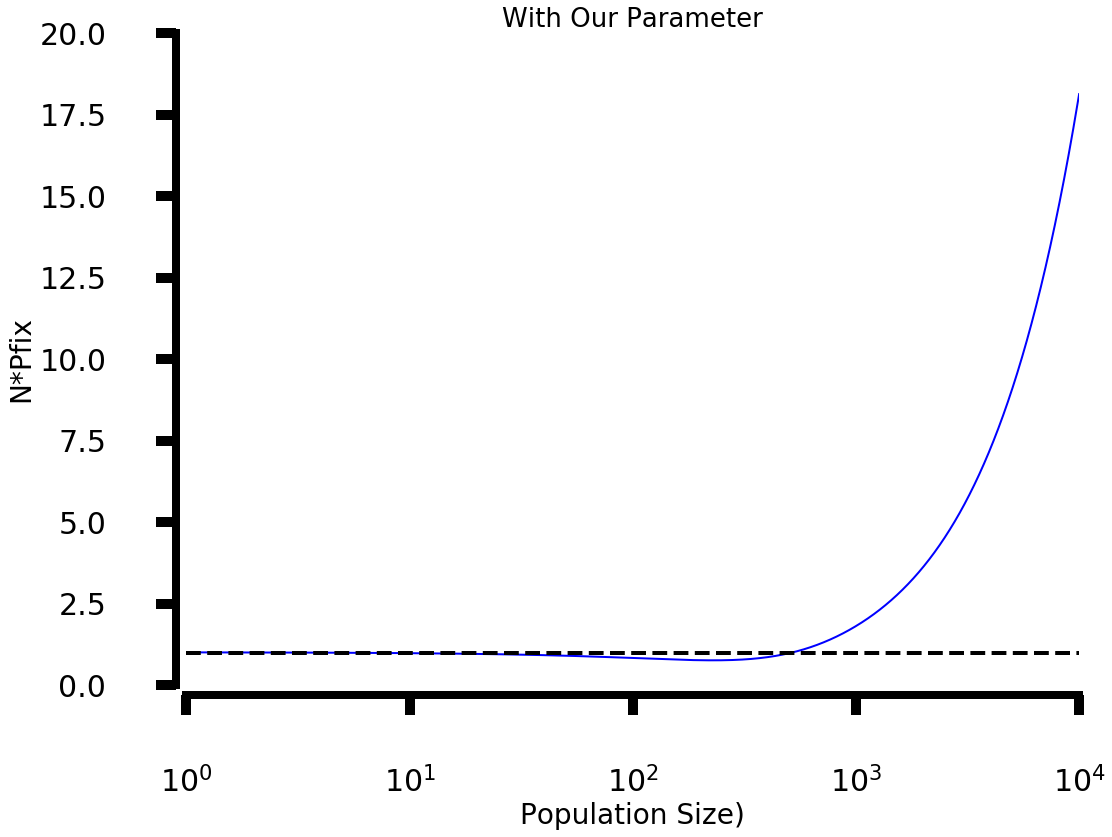

In [8]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(1,10*1000)
ax.set_ylim(0,20)

t = np.arange(10*1000)

s = result


ax.set_title('With Our Parameter', fontsize =26)
ax.set_xlabel('Population Size)', fontsize =28)
ax.set_ylabel('N*Pfix', fontsize =28)



ax.plot(t,s,'b', linewidth=2.0, alpha =1)
ax.set_xscale('log', basex=10)

plt.axhline(y= 1, linewidth=4.0, color ='k',ls ='dashed')


ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))


plt.legend(loc=2, frameon=False, prop={'size':20})

# plt.show()
# plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

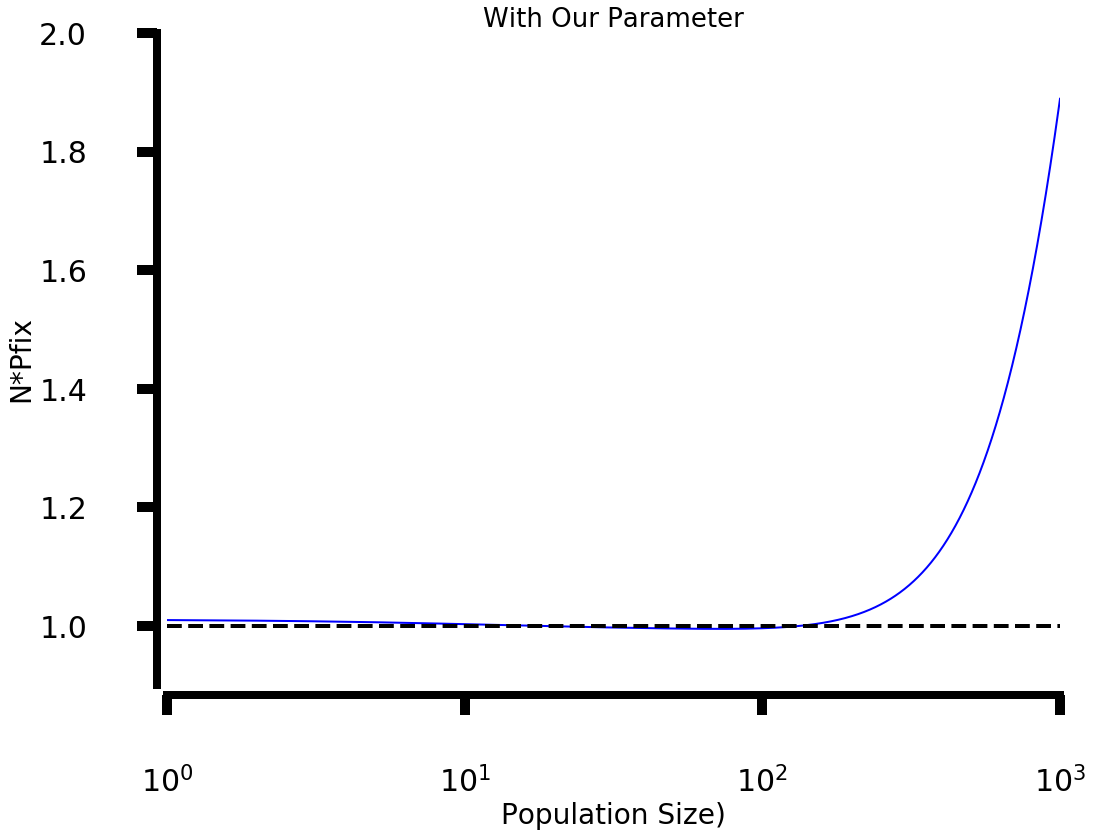

In [9]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(1,1000)
ax.set_ylim(0.9,2)

t = np.arange(10000)

s = result


ax.set_title('With Our Parameter', fontsize =26)
ax.set_xlabel('Population Size)', fontsize =28)
ax.set_ylabel('N*Pfix', fontsize =28)



ax.plot(t,s,'b', linewidth=2.0, alpha =1)
ax.set_xscale('log', basex=10)

plt.axhline(y= 1, linewidth=4.0, color ='k',ls ='dashed')


ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))


plt.legend(loc=2, frameon=False, prop={'size':20})



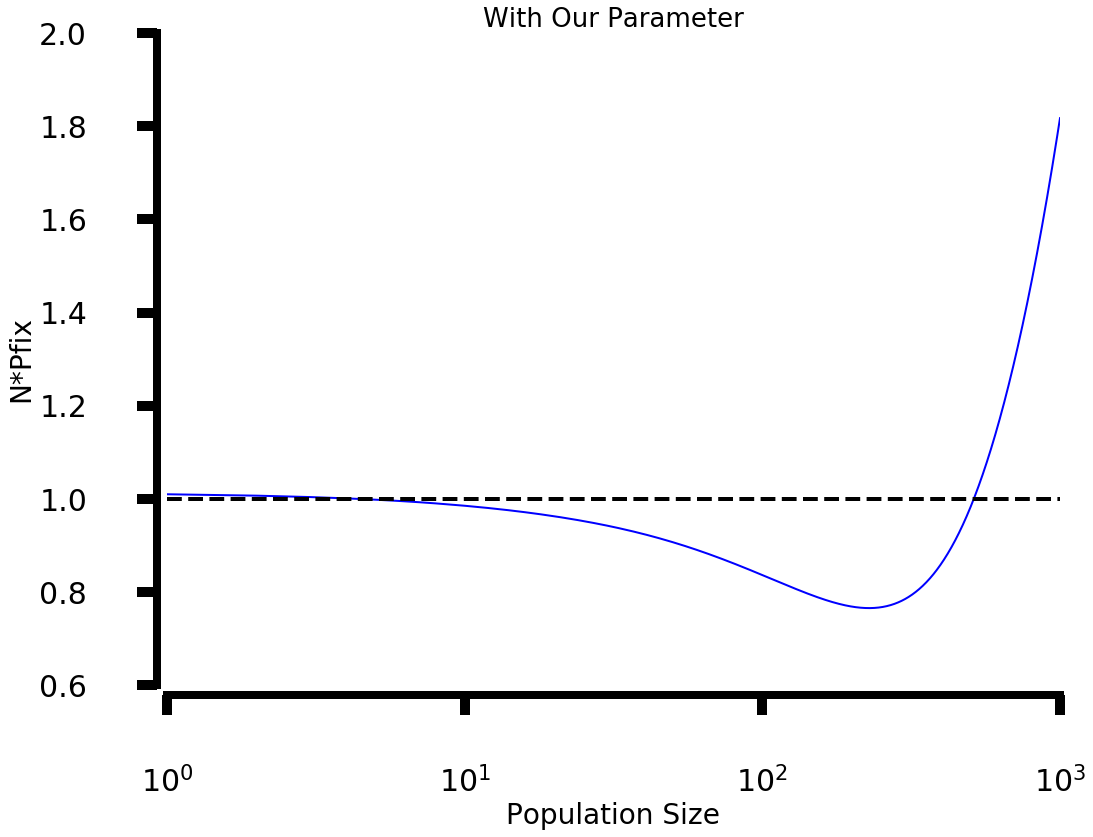

In [10]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(1,1000)
ax.set_ylim(0.6,2)

t = np.arange(10000)

s = result


ax.set_title('With Our Parameter', fontsize =26)
ax.set_xlabel('Population Size', fontsize =28)
ax.set_ylabel('N*Pfix', fontsize =28)



ax.plot(t,s,'b', linewidth=2.0, alpha =1)
ax.set_xscale('log', basex=10)

plt.axhline(y= 1, linewidth=4.0, color ='k',ls ='dashed')


ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))


plt.legend(loc=2, frameon=False, prop={'size':20})



In [11]:
for i in range(len(result)):
    if result[i]<1 and result[i+1]>=1:
        print i

513


In [12]:
result[1]

1.01

In [13]:
result[513]

0.9990672020551673

In [14]:
result[514]

1.0004533953159997

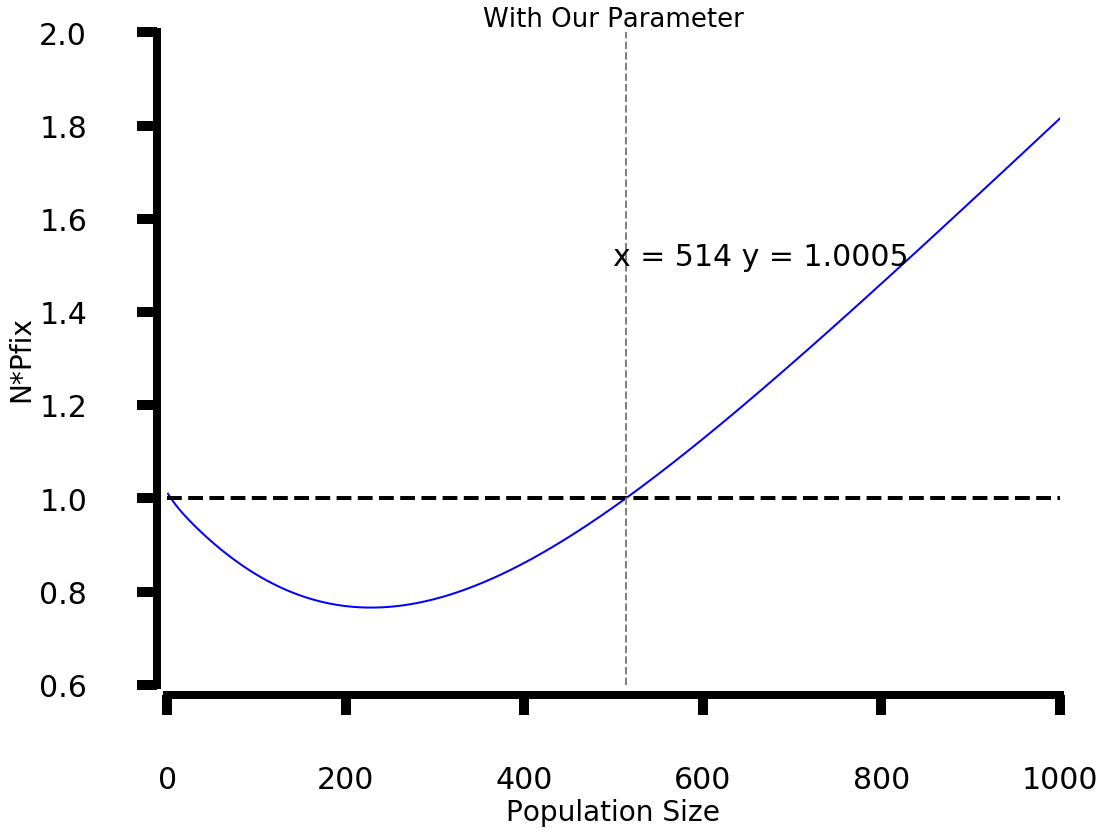

In [74]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(0,1000)
ax.set_ylim(0.6,2)

t = np.arange(10000)

s = result


ax.set_title('With Our Parameter', fontsize =26)
ax.set_xlabel('Population Size', fontsize =28)
ax.set_ylabel('N*Pfix', fontsize =28)



ax.plot(t,s,'b', linewidth=2.0, alpha =1)
# ax.set_xscale('log', basex=10)

plt.axhline(y= 1, linewidth=4.0, color ='k',ls ='dashed')
# plt.axvline(x= 500, linewidth=2.0, color ='grey',ls ='dashed')
plt.axvline(x= 514, linewidth=2.0, color ='grey',ls ='dashed')

plt.text(500,1.5, "x = 514 y = 1.0005")

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))


plt.legend(loc=2, frameon=False, prop={'size':20})



In [15]:
delu3 = ((1.9**10) - 1)*(0.1*2/45)
uben3 = 0.01*0.1*2/45
udel3 = 0.1*2/45
sben3 = 0.1

In [16]:
n_list = np.arange(10000)

result3 = []

for i in n_list:
    result3.append(p_mutator(i, delu3, uben3, udel3, sben3))

C:\Users\ustzh\Anaconda2\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in double_scalars
  
C:\Users\ustzh\Anaconda2\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in double_scalars
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\ustzh\Anaconda2\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: overflow encountered in exp
  


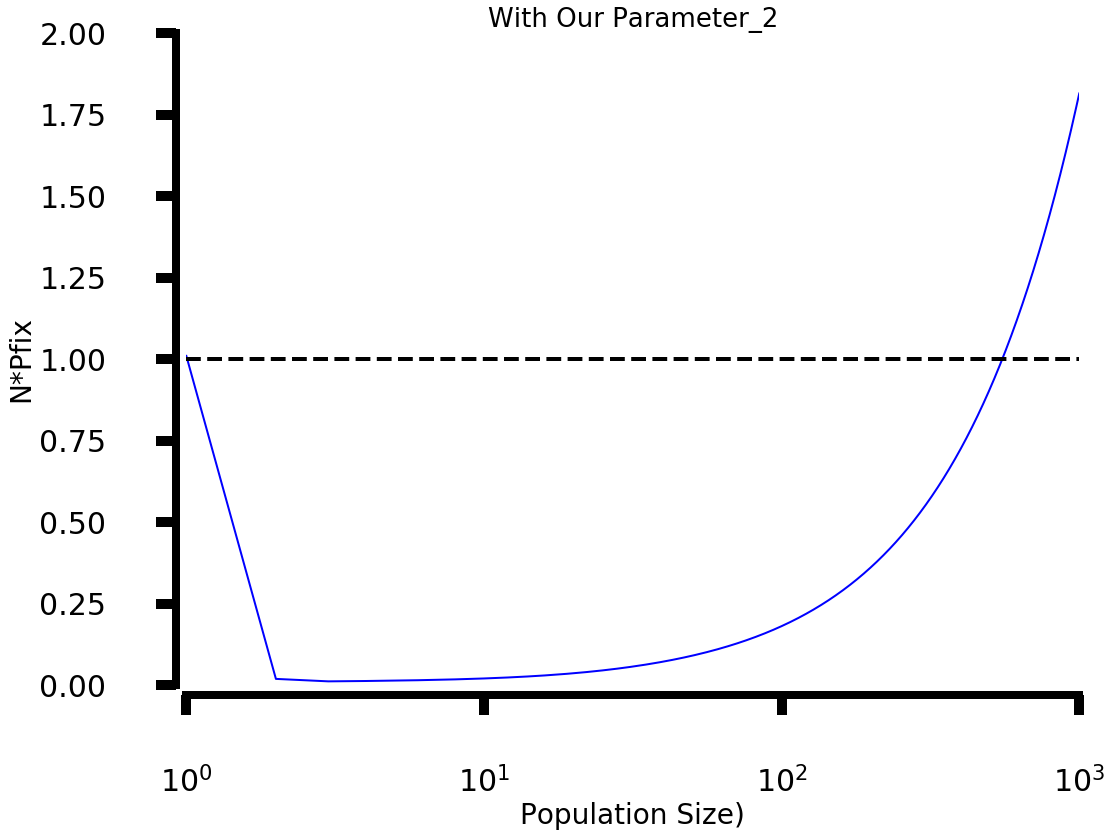

In [17]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(1,1000)
ax.set_ylim(0,2)

t = np.arange(10000)

s = result3


ax.set_title('With Our Parameter_2', fontsize =26)
ax.set_xlabel('Population Size)', fontsize =28)
ax.set_ylabel('N*Pfix', fontsize =28)



ax.plot(t,s,'b', linewidth=2.0, alpha =1)
ax.set_xscale('log', basex=10)

plt.axhline(y= 1, linewidth=4.0, color ='k',ls ='dashed')


ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))


plt.legend(loc=2, frameon=False, prop={'size':20})



In [18]:
for i in range(len(result3)):
    if result3[i]<1 and result3[i+1]>=1:
        print i

551


In [20]:
result3[552]

1.0006062430095404

## Repeat using the parameters in the paper

In [20]:
delu2 = 99*(10**(-4))
uben2 = 10**(-6)
udel2 = 10**(-4)
sben2 = 0.1

In [21]:
n_list = np.arange(10000)

result2 = []

for i in n_list:
    result2.append(p_mutator(i, delu2, uben2, udel2, sben2))

C:\Users\ustzh\Anaconda2\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in double_scalars
  
C:\Users\ustzh\Anaconda2\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in double_scalars
  This is separate from the ipykernel package so we can avoid doing imports until


In [22]:
for i in range(len(result2)):
    if result2[i]<1 and result2[i+1]>=1:
        print i

551


In [23]:
result2.index(min(result2[1:]))

169

In [24]:
result2[300]

0.559639472234402

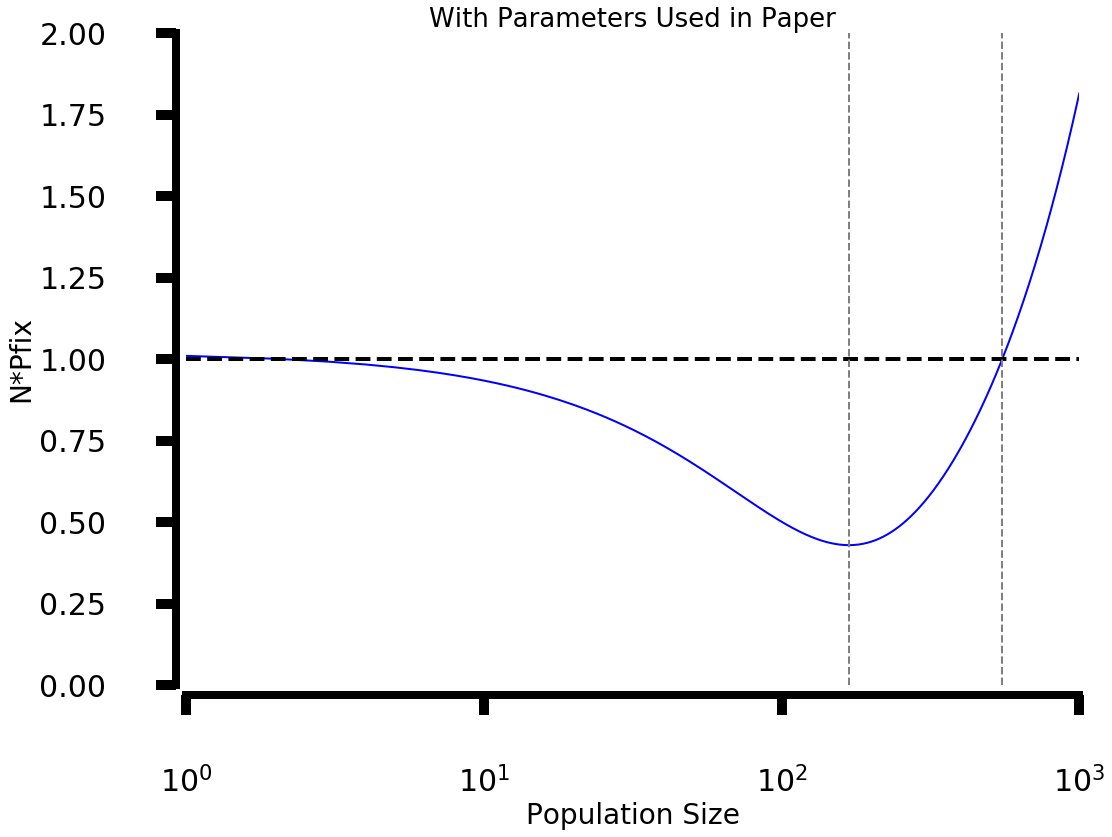

In [25]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(1,1000)
ax.set_ylim(0,2)

t = np.arange(10000)

s = result2


ax.set_title('With Parameters Used in Paper', fontsize =26)
ax.set_xlabel('Population Size', fontsize =28)
ax.set_ylabel('N*Pfix', fontsize =28)



ax.plot(t,s,'b', linewidth=2.0, alpha =1)
ax.set_xscale('log', basex=10)

plt.axhline(y= 1, linewidth=4.0, color ='k',ls ='dashed')
plt.axvline(x= 551, linewidth=2.0, color ='grey',ls ='dashed')
plt.axvline(x= 169, linewidth=2.0, color ='grey',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))


plt.legend(loc=2, frameon=False, prop={'size':20})



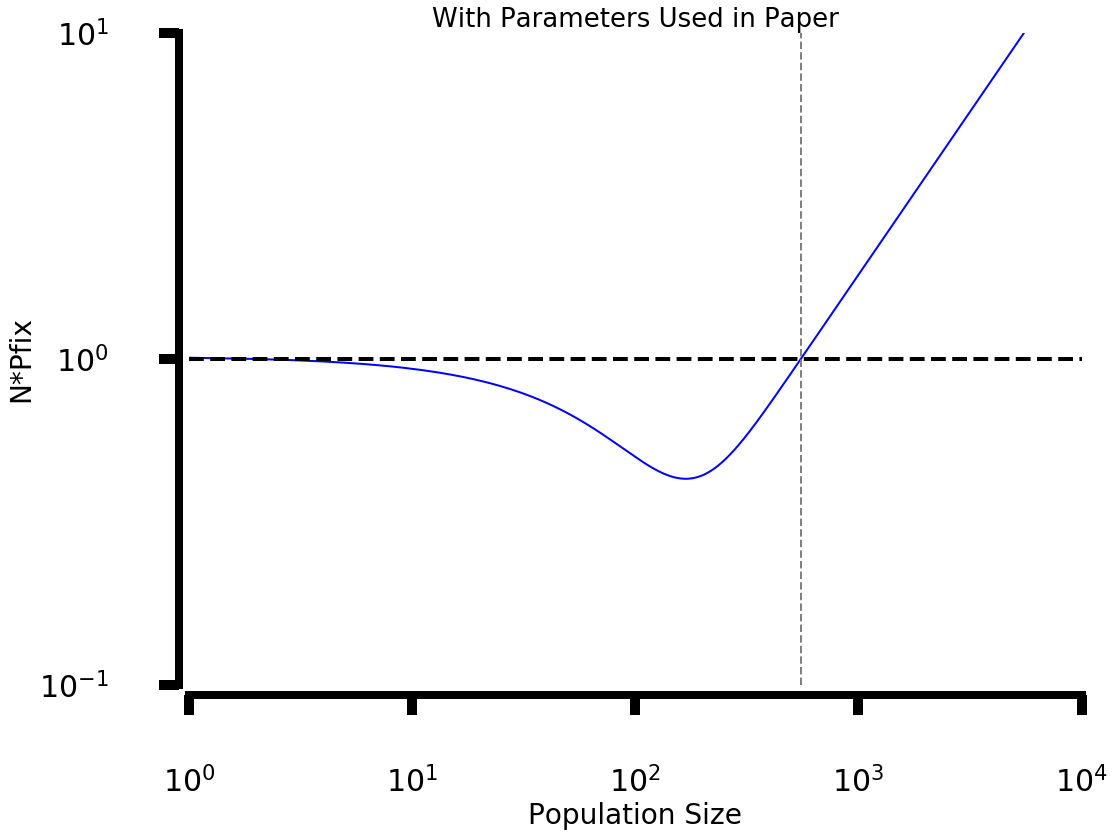

In [15]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(1,10000)
ax.set_ylim(0.1,10)

t = np.arange(10000)

s = result2


ax.set_title('With Parameters Used in Paper', fontsize =26)
ax.set_xlabel('Population Size', fontsize =28)
ax.set_ylabel('N*Pfix', fontsize =28)



ax.plot(t,s,'b', linewidth=2.0, alpha =1)
ax.set_xscale('log', basex=10)
ax.set_yscale('log')


plt.axhline(y= 1, linewidth=4.0, color ='k',ls ='dashed')
plt.axvline(x= 551, linewidth=2.0, color ='grey',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))


plt.legend(loc=2, frameon=False, prop={'size':20})



## Repeat using the parameters in the paper (10* Mu)

In [16]:
delu4 = 99*(10**(-3))
uben4 = 10**(-5)
udel4 = 10**(-3)
sben4 = 0.1

In [17]:
n_list = np.arange(10000)

result = []

for i in n_list:
    result.append(p_mutator(i, delu4, uben4, udel4, sben4))

C:\Users\ustzh\Anaconda2\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in double_scalars
  
C:\Users\ustzh\Anaconda2\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in double_scalars
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\ustzh\Anaconda2\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: overflow encountered in exp
  


In [18]:
result[-1]

18.1251119997326

In [19]:
for i in range(len(result)):
    if result[i]<1 and result[i+1]>=1:
        print i

551


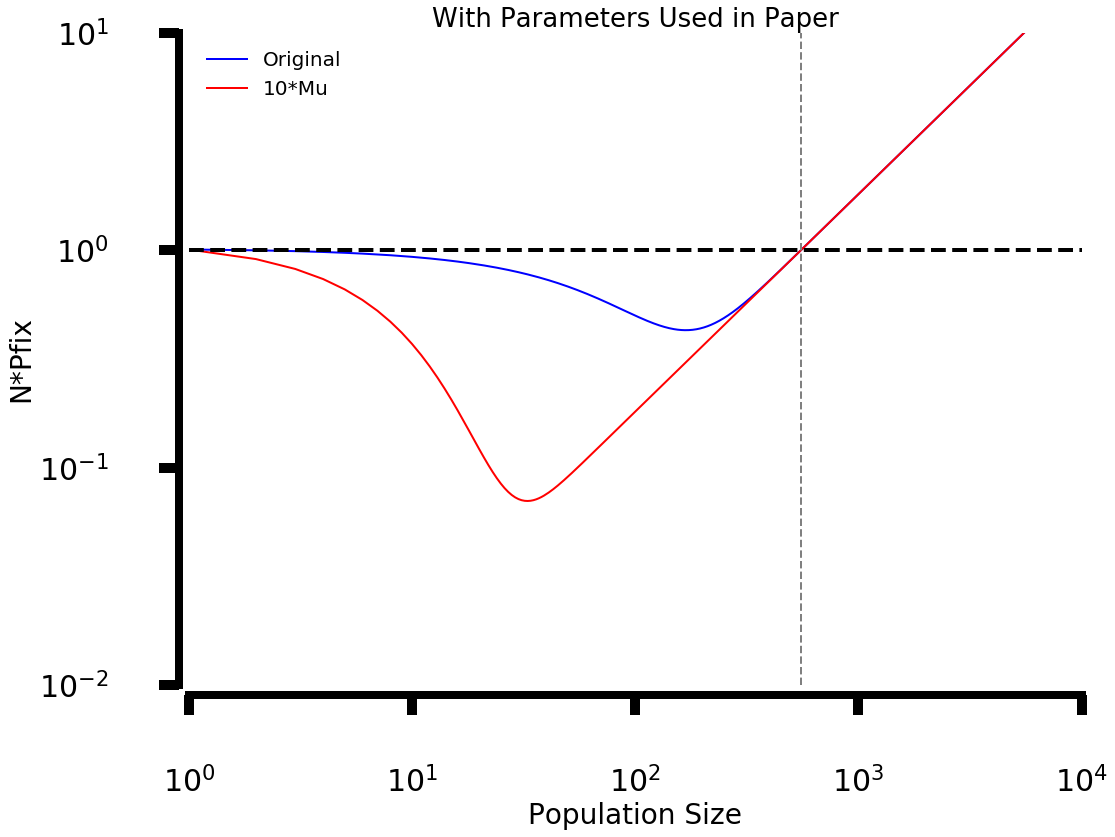

In [29]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(1,10000)
ax.set_ylim(0.01,10)

t = np.arange(10000)

s = result2
s2 = result


ax.set_title('With Parameters Used in Paper', fontsize =26)
ax.set_xlabel('Population Size', fontsize =28)
ax.set_ylabel('N*Pfix', fontsize =28)



ax.plot(t,s,'b', label = 'Original', linewidth=2.0, alpha =1)
ax.plot(t,s2,'r',label =  '10*Mu', linewidth=2.0, alpha =1)
ax.set_xscale('log', basex=10)
ax.set_yscale('log')


plt.axhline(y= 1, linewidth=4.0, color ='k',ls ='dashed')
plt.axvline(x= 551, linewidth=2.0, color ='grey',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))


plt.legend(loc=2, frameon=False, prop={'size':20})

